In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import trapezoid, cumulative_trapezoid
import emcee
from multiprocessing import Pool
import time
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# =========================
# Loading CC data
# =========================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err  = df_cc["H_cc_err"].to_numpy(float)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_MW_total  = DM_MW + 50.0          # MW ISM + halo contribution [pc/cm^3]
DM_ext_obs   = DM_obs - DM_MW_total  # extragalactic DM [pc/cm^3]

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
w0_min,       w0_max       = -3.0,   1.0
wa_min,       wa_max       = -3.0,   2.0
sig_host_min, sig_host_max = 0.2,    2.0
e_mu_min,     e_mu_max     = 20.0,   200.0

# Gaussian prior
mu_Ob, sigma_Ob = 0.0495, 0.0025

# Physical constants
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc  = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical/cosmological parameters
f_IGM = 0.83
chi_e = 0.875

# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)

In [4]:
# ==============================
# Hubble functions
# ==============================

# Normalized Hubble parameter
def E_CPL(z, Om0, w0, wa):
    Om = Om0 * (1 + z)**3

    # Dark energy density
    Ode0 = 1 - Om0
    power = 3*(1 + w0 + wa)
    fde = np.exp(-3*wa*z/(1+z))
    Ode = Ode0 * (1 + z)**power * fde
    return np.sqrt(Om + Ode)


# Hubble parameter
def H_CPL(z, H0, Om0, w0, wa):
    return H0 * E_CPL(z, Om0, w0, wa)


# ====================================================
# Theoretical IGM dispersion measure [pc/cm^3]
# ====================================================

def DM_IGM_CPL(z, H0, Om0, Ob, w0, wa):
    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_grid    = H_CPL(z_grid, H0, Om0, w0, wa)
    integrand = (1 + z_grid) / H_grid
    I_grid    = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, I_grid)
    DM_IGM_z    = prefactor * Ob * H0**2 * I_z                      # Before units conversion
    DM_IGM_corr = DM_IGM_z * (km_to_pc / (m2_to_cm2 * Mpc_to_cm))   # Physical units (pc cm^-3)
    return DM_IGM_corr

In [5]:
# ====================================================
# CC + FRB Likelihood
# ====================================================

# Log-priors
def lnprior_cc_frb(theta):
    H0, Om0, Ob, w0, wa, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):        return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):       return -np.inf
    if not (0.0          <  Ob         < Om0):            return -np.inf
    if not (w0_min       <= w0         <= w0_max):        return -np.inf
    if not (wa_min       <= wa         <= wa_max):        return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max):  return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):      return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    return lp_Ob


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM, sigma_host, exp_mu, npts=600):
    mu_host = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)              
    DM_hosp_grid = DM_hosp_grid[None, :]                      
    DM_ext_array = DM_ext_obs[:, None]                    
    DM_IGM_array = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None]) 
    sigma_IGM_array = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    P_IGM = (1.0 / (np.sqrt(2*np.pi) * sigma_IGM_array)) \
            * np.exp(-0.5 * ((DM_IGM_array - DM_IGM_mean_array)/sigma_IGM_array)**2)

    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2*np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host)/sigma_host)**2)

    integrand = P_IGM * P_host 
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Log-likelihood
def lnlike_cc_frb(theta, z_cc, H_obs, H_err,
                         z_frb, DM_ext_obs, npts=300):
    H0, Om0, Ob, w0, wa, sigma_host, exp_mu = theta
    # -------------------------------------------------
    # CC part
    # -------------------------------------------------
    H_model = H_CPL(z_cc, H0, Om0, w0, wa)
    chi2_cc = np.sum(((H_obs - H_model) / H_err)**2) 
    lnL_cc  = -0.5 * chi2_cc
    # -------------------------------------------------
    # FRB part
    # -------------------------------------------------
    DM_IGM_mean = DM_IGM_CPL(z_frb, H0, Om0, Ob, w0, wa)
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                  sigma_IGM, sigma_host, exp_mu, npts=npts)
    lnL_frb = np.sum(np.log(P_total))
    return lnL_cc + lnL_frb

# Log-posterior
def lnprob_cc_frb(theta, z_cc, H_obs, H_err,
                         z_frb, DM_ext_obs):
    lp = lnprior_cc_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = lnlike_cc_frb(theta, z_cc, H_obs, H_err,
                         z_frb, DM_ext_obs, npts=300)
    return lp + ll


# ====================================================
# Quick test
# ====================================================

theta_test = [70, 0.3, 0.0494, -1.0, 0.0, 0.7, 120]
print("CC + FRB log-posterior =",
       lnprob_cc_frb(theta_test, z_cc, H_obs, H_err,
                                 z_frb, DM_ext_obs))

CC + FRB log-posterior = -657.7060745713379


In [6]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 7
nwalkers = 56
nsteps   = 20000

theta0 = np.array([70.0, 0.3, 0.0495, -1.0, 0.0, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001,  0.1, 0.2, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + FRB) ===")
t_mcmc = time.time()

with Pool(processes=nwalkers) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, lnprob_cc_frb,
        args=(z_cc, H_obs, H_err, z_frb, DM_ext_obs)
    )
    sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + FRB) ===


100%|██████████| 20000/20000 [05:20<00:00, 62.34it/s]


MCMC completed in 5.4 min


In [7]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.418
Acceptance status: IDEAL

Max autocorrelation time τ_max = 184.09
Chain length / τ_max           = 108.6
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 552 steps (2.8%)
Thin (τ_max/2)                 = 92
Minimum N_eff                  = 5916
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [8]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log    = sampler.get_chain(discard=nburn, thin=nthin, flat=True)       # Apply thin
flat_log      = sampler.get_chain(discard=nburn, flat=True)                   # No thin
flat_samples  = flat_log.copy()

# Save flat samples
fname = "flat_samples_CPL_cc_frb.npy"
np.save(fname, flat_samples)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used                : {nburn} steps")
print(f"Saved to                    : {fname}")


Final independent samples : 1089088
Burn-in used                : 552 steps
Saved to                    : flat_samples_CPL_cc_frb.npy


Removed no burn in


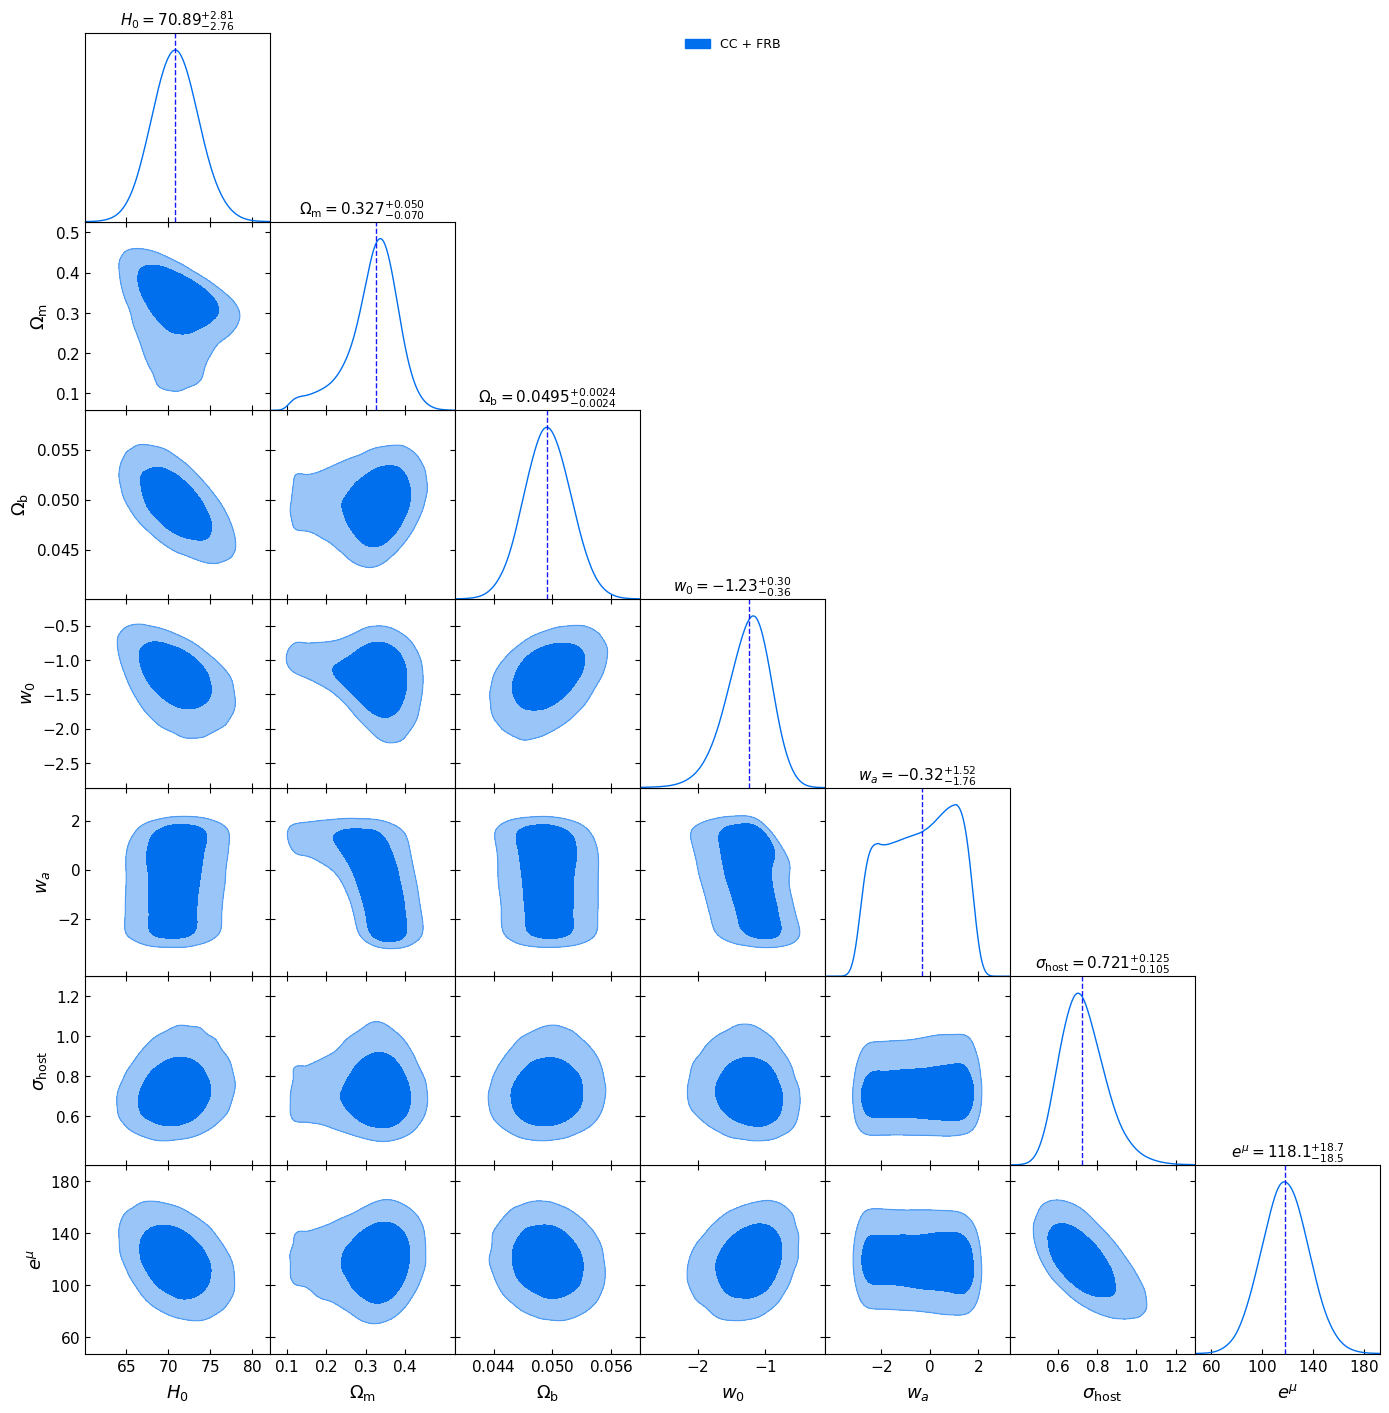

In [9]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "w0", "wa", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}", r"w_0", r"w_a",
                r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + FRB"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "w0": ".2f", "wa": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68

    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = "Corner_CPL_cc_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("w0", 3), ("wa", 4), ("sigma_host", 5), ("exp_mu", 6)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "w0": ".2f", "wa": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (CPL model | CC + FRB data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")

print("\n" + "="*60)


    Final Inference Results (CPL model | CC + FRB data)     

  H0:
    70.89 +2.81 -2.76  (68% CL)
    70.89 +5.67 -5.41  (95% CL)

  Om0:
    0.327 +0.050 -0.070  (68% CL)
    0.327 +0.098 -0.182  (95% CL)

  Ob:
    0.0495 +0.0024 -0.0024  (68% CL)
    0.0495 +0.0048 -0.0047  (95% CL)

  w0:
    -1.23 +0.30 -0.36  (68% CL)
    -1.23 +0.57 -0.76  (95% CL)

  wa:
    -0.32 +1.52 -1.76  (68% CL)
    -0.32 +2.16 -2.53  (95% CL)

  sigma_host:
    0.721 +0.125 -0.105  (68% CL)
    0.721 +0.275 -0.190  (95% CL)

  exp_mu:
    118.1 +18.7 -18.5  (68% CL)
    118.1 +37.3 -36.2  (95% CL)



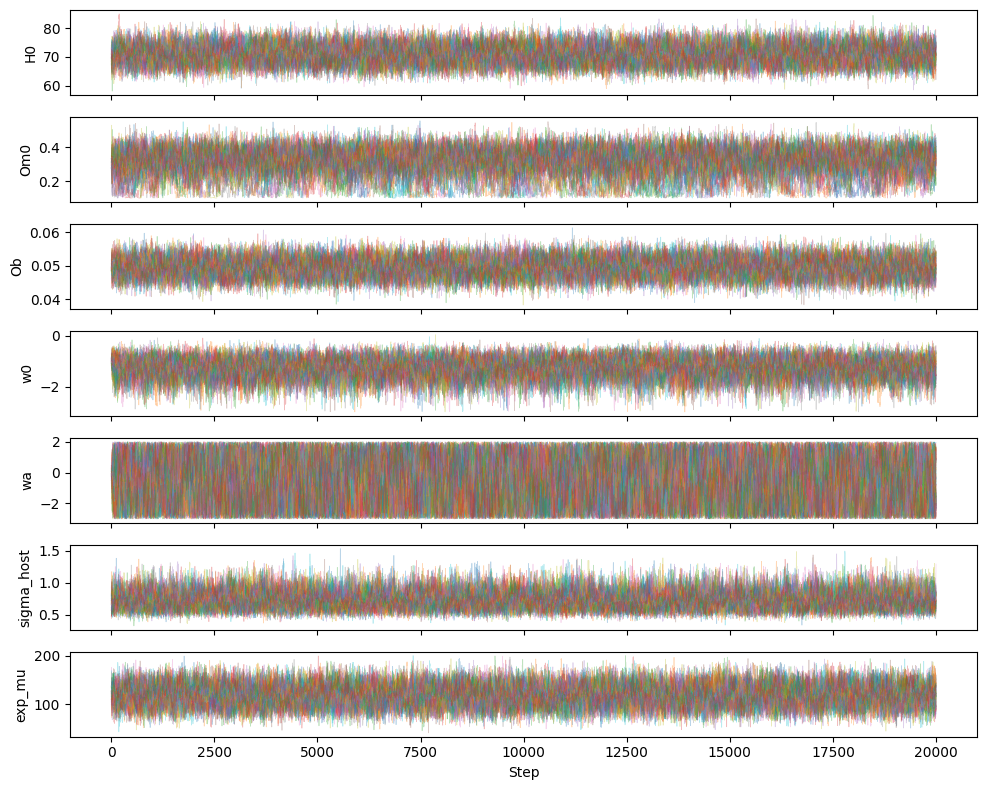

In [11]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(7, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "w0", "wa", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()